# 🧹 Depuración de Dataset: Data Recordings

Este notebook realiza la limpieza y depuración del archivo `1_Data_Recordings.csv`.

**Problemas identificados:**
- `fecha` y `hora` como strings — se deben convertir a tipos datetime
- `duracion_sesion` en formato HH:MM:SS como string — convertir a segundos numérico
- `referente` con 56% de nulos (tráfico directo legítimo, se documenta)
- Outliers en `clicks_por_pagina` (máx 255) y `duracion_sesion_segundos` (máx 11,863s ≈ 3.3h)
- Columnas binarias (`abandono_rapido`, `posible_frustracion`, etc.) a verificar
- 58 filas duplicadas
- URLs sin normalizar
- Dispositivos `Email` y `Other` como categorías marginales a revisar

---

## 📦 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Para Colab: si el archivo está en Drive, montarlo
# from google.colab import drive
# drive.mount('/content/drive')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 📂 2. Carga del dataset

In [2]:
FILE_PATH = '1_Data_Recordings.csv'  # Ajusta la ruta si es necesario

df_raw = pd.read_csv(FILE_PATH, low_memory=False)

print(f'✅ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head()

✅ Dataset cargado: 67,414 filas × 22 columnas


,fecha,hora,duracion_sesion,direccion_url_entrada,direccion_url_salida,referente,id_usuario_clarity,explorador,dispositivo,sistema_operativo,...,clics_sesion,duracion_sesion_segundos,abandono_rapido,clicks_por_pagina,tiempo_por_pagina,interaccion_total,posible_frustracion,standarized_engagement_score,entrada_es_home,trafico_externo
0,03/13/2026,10:49,00:00:16,https://cloudlabslearning.com/,https://cloudlabslearning.com/,https://www.google.com/,bx1vzf,Chrome,PC,Windows,...,2,16.0,1,2.0,16.0,3,0,-0.392629,0,1
1,03/13/2026,10:48,00:00:05,https://cloudlabslearning.com/,https://cloudlabslearning.com/#error=login_req...,https://www.google.com/,1h7fns5,Chrome,PC,Windows,...,2,5.0,0,1.0,2.5,4,0,-0.400954,0,1
2,03/13/2026,10:48,00:00:06,https://cloudlabslearning.com/#error=login_req...,https://cloudlabslearning.com/#error=login_req...,NaN,15ymnwq,Chrome,PC,Windows,...,2,6.0,1,2.0,6.0,3,0,-0.416415,0,0
3,03/13/2026,10:46,00:00:06,https://cloudlabslearning.com/#error=login_req...,https://cloudlabslearning.com/#error=login_req...,NaN,o27bll,Chrome,PC,Windows,...,3,6.0,1,3.0,6.0,4,0,-0.404522,0,0
4,03/13/2026,10:46,00:00:39,https://cloudlabslearning.com/request-demo?err...,https://cloudlabslearning.com/request-demo?err...,NaN,6791px,ChromeMobile,Mobile,Android,...,5,39.0,1,5.0,39.0,6,0,-0.302242,0,0


## 🔍 3. Diagnóstico inicial

In [3]:
print('=== TIPOS DE DATOS ===')
print(df_raw.dtypes)
print()
print('=== DESCRIPCIÓN ESTADÍSTICA ===')
df_raw.describe(include='all')

=== TIPOS DE DATOS ===
fecha                            object
hora                             object
duracion_sesion                  object
direccion_url_entrada            object
direccion_url_salida             object
referente                        object
id_usuario_clarity               object
explorador                       object
dispositivo                      object
sistema_operativo                object
pais                             object
recuento_paginas                  int64
clics_sesion                      int64
duracion_sesion_segundos        float64
abandono_rapido                   int64
clicks_por_pagina               float64
tiempo_por_pagina               float64
interaccion_total                 int64
posible_frustracion               int64
standarized_engagement_score    float64
entrada_es_home                   int64
trafico_externo                   int64
dtype: object

=== DESCRIPCIÓN ESTADÍSTICA ===


,fecha,hora,duracion_sesion,direccion_url_entrada,direccion_url_salida,referente,id_usuario_clarity,explorador,dispositivo,sistema_operativo,...,clics_sesion,duracion_sesion_segundos,abandono_rapido,clicks_por_pagina,tiempo_por_pagina,interaccion_total,posible_frustracion,standarized_engagement_score,entrada_es_home,trafico_externo
count,67414,67414,67414,67414,67414,29403,67414,67414,67414,67414,...,67414.000000,67414.000000,67414.000000,67414.000000,67414.000000,67414.000000,67414.000000,6.741400e+04,67414.000000,67414.000000
unique,121,1440,2346,15324,18088,252,47997,18,5,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,03/04/2026,10:35,00:00:01,https://cloudlabslearning.com/,https://cloudlabslearning.com/,https://www.google.com/,ymkeij,ChromeMobile,Mobile,Android,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4631,228,4428,27457,23923,22350,143,27051,36854,26266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.140564,164.891996,0.697125,2.312758,79.047201,5.870190,0.033732,-2.740397e-17,0.000252,0.436156
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.904352,395.915956,0.459505,3.810514,166.985387,9.147021,0.180539,1.000000e+00,0.015878,0.495911
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.000000,0.000000,0.000000,0.500000,1.000000,0.000000,-4.520937e-01,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,9.000000,0.000000,0.000000,8.000000,2.000000,0.000000,-4.116575e-01,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,27.000000,1.000000,1.500000,21.000000,3.000000,0.000000,-3.521925e-01,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.000000,112.000000,1.000000,3.000000,66.000000,6.000000,0.000000,-8.816766e-02,0.000000,1.000000


In [ ]:
# Análisis de nulos
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos}).sort_values('% Nulos', ascending=False)

print('=== VALORES NULOS POR COLUMNA ===')
print(resumen_nulos[resumen_nulos['Nulos'] > 0])

fig, ax = plt.subplots(figsize=(6, 3))
cols_con_nulos = resumen_nulos[resumen_nulos['% Nulos'] > 0]
ax.barh(cols_con_nulos.index, cols_con_nulos['% Nulos'], color='#e74c3c')
ax.set_xlabel('% de valores nulos')
ax.set_title('Columnas con Nulos')
plt.tight_layout()
plt.show()

In [4]:
n_dup = df_raw.duplicated().sum()
print(f'Filas duplicadas: {n_dup} ({n_dup/len(df_raw)*100:.2f}%)')

Filas duplicadas: 58 (0.09%)


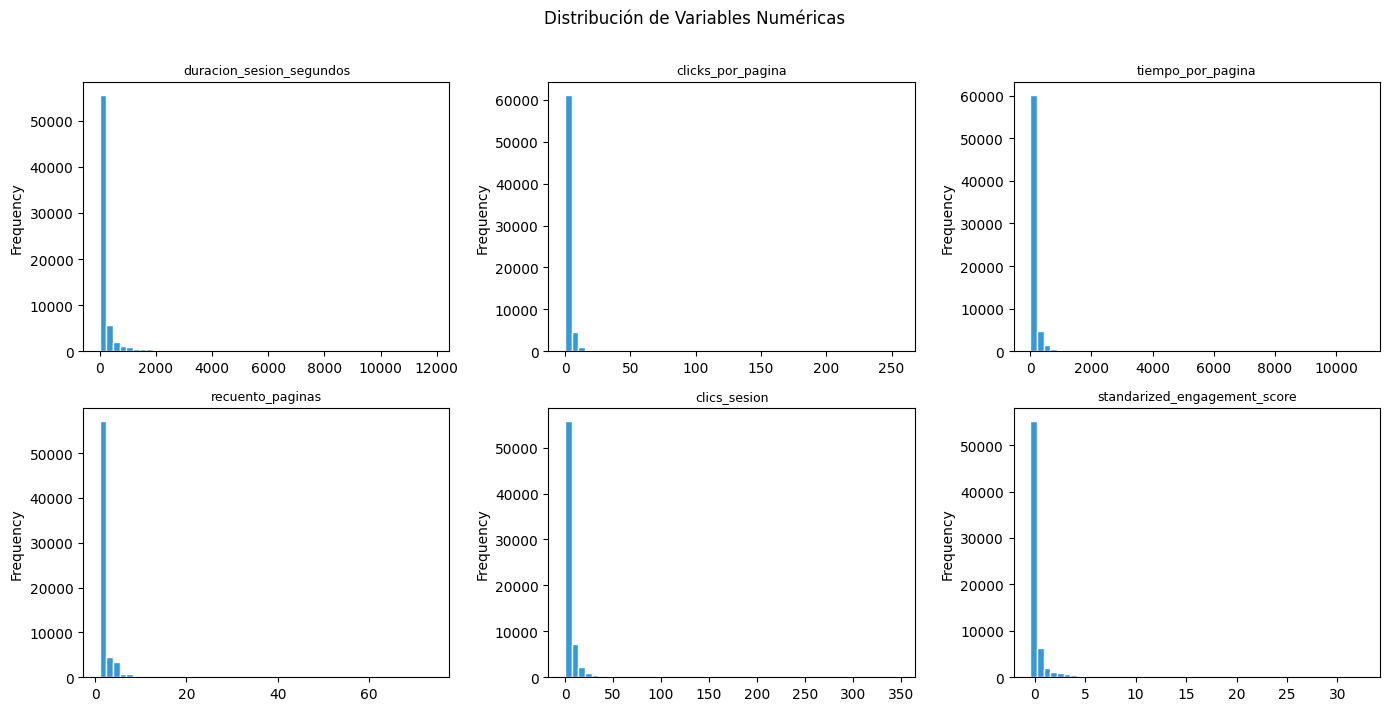


=== ESTADÍSTICAS NUMÉRICAS ===


,duracion_sesion_segundos,clicks_por_pagina,tiempo_por_pagina,recuento_paginas,clics_sesion,standarized_engagement_score
count,67414.00,67414.00,67414.00,67414.00,67414.00,67414.00
mean,164.89,2.31,79.05,1.73,4.14,-0.00
std,395.92,3.81,166.99,1.82,7.90,1.00
min,1.00,0.00,0.50,1.00,0.00,-0.45
25%,9.00,0.00,8.00,1.00,0.00,-0.41
50%,27.00,1.50,21.00,1.00,2.00,-0.35
75%,112.00,3.00,66.00,2.00,5.00,-0.09
max,11863.00,255.00,10888.00,74.00,347.00,32.57


In [5]:
# Distribución de columnas numéricas clave
cols_num = ['duracion_sesion_segundos', 'clicks_por_pagina', 'tiempo_por_pagina',
            'recuento_paginas', 'clics_sesion', 'standarized_engagement_score']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), cols_num):
    df_raw[col].plot(kind='hist', bins=50, ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Distribución de Variables Numéricas', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas de outliers
print('\n=== ESTADÍSTICAS NUMÉRICAS ===')
df_raw[cols_num].describe().round(2)

In [6]:
# Variables categóricas
for col in ['dispositivo', 'sistema_operativo', 'pais', 'explorador']:
    print(f'--- {col} ({df_raw[col].nunique()} únicos) ---')
    print(df_raw[col].value_counts().head(10))
    print()

--- dispositivo (5 únicos) ---
dispositivo
Mobile    36854
PC        28119
Tablet     2437
Email         3
Other         1
Name: count, dtype: int64

--- sistema_operativo (8 únicos) ---
sistema_operativo
Android     26266
Windows     24936
iOS         13024
MacOS        1727
Linux        1015
ChromeOS      435
Ubuntu         10
Unknown         1
Name: count, dtype: int64

--- pais (127 únicos) ---
pais
Colombia         29090
Mexico           20171
Argentina         4483
United States     2694
Spain             1484
Guatemala         1350
Peru               899
Honduras           897
Philippines        718
El Salvador        664
Name: count, dtype: int64

--- explorador (18 únicos) ---
explorador
ChromeMobile       27051
Chrome             24438
MobileSafari        5981
GoogleApp           3542
Edge                2503
SamsungInternet     1259
Safari               745
Opera                610
Firefox              439
EdgeMobile           384
Name: count, dtype: int64



In [7]:
# Columnas binarias
cols_binarias = ['abandono_rapido', 'posible_frustracion', 'entrada_es_home', 'trafico_externo']
for col in cols_binarias:
    vals = sorted(df_raw[col].unique())
    invalidos = [v for v in vals if v not in [0, 1]]
    print(f'{col}: valores únicos = {vals} | Inválidos = {invalidos if invalidos else "ninguno"}')

abandono_rapido: valores únicos = [np.int64(0), np.int64(1)] | Inválidos = ninguno
posible_frustracion: valores únicos = [np.int64(0), np.int64(1)] | Inválidos = ninguno
entrada_es_home: valores únicos = [np.int64(0), np.int64(1)] | Inválidos = ninguno
trafico_externo: valores únicos = [np.int64(0), np.int64(1)] | Inválidos = ninguno


## 🧹 4. Limpieza y depuración

In [8]:
df = df_raw.copy()
print(f'Tamaño inicial: {df.shape}')

Tamaño inicial: (67414, 22)


In [9]:
# PASO 4.1 — Eliminar duplicados exactos
antes = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'✅ Duplicados eliminados: {antes - len(df)} filas | Quedan: {len(df):,}')

✅ Duplicados eliminados: 58 filas | Quedan: 67,356


In [10]:
# PASO 4.2 — Convertir fecha y hora a datetime
df['fecha'] = pd.to_datetime(df['fecha'], format='%m/%d/%Y', errors='coerce')
df['hora'] = pd.to_datetime(df['hora'], format='%H:%M', errors='coerce').dt.time

# Crear columna datetime combinada
df['datetime_sesion'] = pd.to_datetime(
    df['fecha'].astype(str) + ' ' + df['hora'].astype(str),
    errors='coerce'
)

# Extraer componentes útiles
df['dia_semana'] = df['fecha'].dt.day_name()
df['mes'] = df['fecha'].dt.month

fechas_invalidas = df['fecha'].isnull().sum()
print(f'✅ Fechas convertidas | Inválidas: {fechas_invalidas}')
print(f'   Rango: {df["fecha"].min()} → {df["fecha"].max()}')

✅ Fechas convertidas | Inválidas: 0
   Rango: 2025-11-13 00:00:00 → 2026-03-13 00:00:00


In [11]:
# PASO 4.3 — Convertir duracion_sesion (HH:MM:SS) a segundos
def hms_a_segundos(valor):
    """Convierte string HH:MM:SS a entero de segundos."""
    try:
        partes = str(valor).split(':')
        if len(partes) == 3:
            return int(partes[0]) * 3600 + int(partes[1]) * 60 + int(partes[2])
        elif len(partes) == 2:
            return int(partes[0]) * 60 + int(partes[1])
        return np.nan
    except:
        return np.nan

df['duracion_sesion_hms'] = df['duracion_sesion']  # Conservar original
df['duracion_sesion_seg_calc'] = df['duracion_sesion'].apply(hms_a_segundos)

# Verificar consistencia con duracion_sesion_segundos existente
diff = (df['duracion_sesion_seg_calc'] - df['duracion_sesion_segundos']).abs()
inconsistentes = (diff > 1).sum()  # Tolerancia de 1 segundo
print(f'✅ duracion_sesion convertida a segundos')
print(f'   Inconsistencias vs columna original: {inconsistentes} filas')
if inconsistentes > 0:
    print('   ⚠️  Revisar inconsistencias — se conservan ambas columnas para auditoría')

✅ duracion_sesion convertida a segundos
   Inconsistencias vs columna original: 0 filas


In [12]:
# PASO 4.4 — Normalizar URLs
for col in ['direccion_url_entrada', 'direccion_url_salida']:
    df[col] = (
        df[col].astype(str)
        .str.strip()
        .str.lower()
        .str.rstrip('/')        # Eliminar slash final
        .replace('nan', np.nan)
    )
print('✅ URLs normalizadas (lowercase, sin espacios, sin slash final)')
print('   Ejemplos url_entrada:', df['direccion_url_entrada'].unique()[:5])

✅ URLs normalizadas (lowercase, sin espacios, sin slash final)
   Ejemplos url_entrada: ['https://cloudlabslearning.com'
 'https://cloudlabslearning.com/#error=login_required&state=a0efcb5a-3ccf-47b1-8028-52db11a9504a'
 'https://cloudlabslearning.com/#error=login_required&state=8f689cbd-7723-49f4-a2f7-44e85cfedd27'
 'https://cloudlabslearning.com/request-demo?err=subscription_not_found'
 'https://cloudlabslearning.com/#error=login_required&state=666df172-6d68-4582-803e-1e3043f533dc']


In [13]:
# PASO 4.5 — Documentar nulos en referente
# Los nulos en referente = tráfico directo (usuario escribe URL o viene de bookmark)
# Es información válida, NO se eliminan. Se etiquetan explícitamente.

df['referente'] = df['referente'].fillna('(directo)')
print('✅ Nulos en referente reemplazados por "(directo)"')
print(df['referente'].value_counts().head(10))

✅ Nulos en referente reemplazados por "(directo)"
referente
(directo)                             37958
https://www.google.com/               22349
https://platform.cloudlabs.us/         2617
https://youtube.com/                   1065
https://cloudlabslearning.com/          726
https://syndicatedsearch.goog/          652
https://www.uniminuto.edu/              348
https://www.bing.com/                   162
https://login.microsoftonline.com/      125
https://www.youtube.com/                 93
Name: count, dtype: int64


In [14]:
# PASO 4.6 — Tratamiento de outliers con IQR
# Se usa winsorización (capping): los extremos se recortan al límite del IQR
# En lugar de eliminar filas, se conservan pero se marcan

COLS_OUTLIER = ['duracion_sesion_segundos', 'clicks_por_pagina', 'tiempo_por_pagina', 'clics_sesion']
FACTOR_IQR = 3.0  # Factor conservador (3x IQR)

resumen_outliers = []

for col in COLS_OUTLIER:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + FACTOR_IQR * IQR
    limite_inf = max(0, Q1 - FACTOR_IQR * IQR)  # No negativos

    n_outliers = ((df[col] > limite_sup) | (df[col] < limite_inf)).sum()
    resumen_outliers.append({'Columna': col, 'Outliers': n_outliers,
                              'Límite inf': round(limite_inf, 2), 'Límite sup': round(limite_sup, 2)})

    # Winsorización
    df[col + '_original'] = df[col]  # Guardar original
    df[col] = df[col].clip(lower=limite_inf, upper=limite_sup)

print('✅ Outliers tratados con winsorización (factor IQR =', FACTOR_IQR, ')')
pd.DataFrame(resumen_outliers)

✅ Outliers tratados con winsorización (factor IQR = 3.0 )


,Columna,Outliers,Límite inf,Límite sup
0,duracion_sesion_segundos,6847,0,421.0
1,clicks_por_pagina,1110,0,12.0
2,tiempo_por_pagina,6755,0,240.0
3,clics_sesion,2057,0,20.0


In [15]:
# PASO 4.7 — Estandarizar columnas categóricas
cols_cat = ['dispositivo', 'sistema_operativo', 'pais', 'explorador']

for col in cols_cat:
    df[col] = df[col].astype(str).str.strip()

# Agrupar dispositivos marginales
df['dispositivo'] = df['dispositivo'].replace({'Email': 'Other', '': 'Unknown'})

print('✅ Categorías estandarizadas')
print('dispositivo:', df['dispositivo'].value_counts().to_dict())

✅ Categorías estandarizadas
dispositivo: {'Mobile': 36800, 'PC': 28116, 'Tablet': 2436, 'Other': 4}


In [16]:
# PASO 4.8 — Validar columnas binarias (deben ser solo 0 o 1)
cols_binarias = ['abandono_rapido', 'posible_frustracion', 'entrada_es_home', 'trafico_externo']

for col in cols_binarias:
    invalidos = df[~df[col].isin([0, 1])]
    if len(invalidos) > 0:
        print(f'⚠️  {col}: {len(invalidos)} valores inválidos → convertidos a NaN')
        df.loc[~df[col].isin([0, 1]), col] = np.nan
    else:
        print(f'✅ {col}: OK (solo 0 y 1)')

✅ abandono_rapido: OK (solo 0 y 1)
✅ posible_frustracion: OK (solo 0 y 1)
✅ entrada_es_home: OK (solo 0 y 1)
✅ trafico_externo: OK (solo 0 y 1)


In [17]:
# PASO 4.9 — Optimizar tipos de datos para memoria
for col in cols_binarias:
    df[col] = df[col].astype('Int8')  # Nullable integer

for col in ['recuento_paginas', 'clics_sesion', 'interaccion_total']:
    df[col] = df[col].astype('Int32')

for col in cols_cat:
    df[col] = df[col].astype('category')

print('✅ Tipos de datos optimizados')

✅ Tipos de datos optimizados


In [18]:
# PASO 4.10 — Resetear índice
df.reset_index(drop=True, inplace=True)
print(f'✅ Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Dataset limpio: 67,356 filas × 31 columnas


## 📊 5. Reporte final de calidad

In [19]:
print('========================================')
print('      REPORTE DE DEPURACIÓN FINAL       ')
print('========================================')
print(f'Filas originales:   {df_raw.shape[0]:>10,}')
print(f'Filas finales:      {df.shape[0]:>10,}')
print(f'Filas eliminadas:   {df_raw.shape[0] - df.shape[0]:>10,}')
print(f'Columnas orig.:     {df_raw.shape[1]:>10}')
print(f'Columnas finales:   {df.shape[1]:>10}  (incluye nuevas derivadas)')
print()
print('--- Columnas nuevas creadas ---')
nuevas = [c for c in df.columns if c not in df_raw.columns]
for c in nuevas:
    print(f'  + {c}')
print()
print('--- Nulos restantes ---')
nulos_fin = df.isnull().sum()
nulos_fin_filtrado = nulos_fin[nulos_fin > 0]
if len(nulos_fin_filtrado) == 0:
    print('  Sin nulos relevantes ✅')
else:
    print(nulos_fin_filtrado)

      REPORTE DE DEPURACIÓN FINAL       
Filas originales:       67,414
Filas finales:          67,356
Filas eliminadas:           58
Columnas orig.:             22
Columnas finales:           31  (incluye nuevas derivadas)

--- Columnas nuevas creadas ---
  + datetime_sesion
  + dia_semana
  + mes
  + duracion_sesion_hms
  + duracion_sesion_seg_calc
  + duracion_sesion_segundos_original
  + clicks_por_pagina_original
  + tiempo_por_pagina_original
  + clics_sesion_original

--- Nulos restantes ---
  Sin nulos relevantes ✅


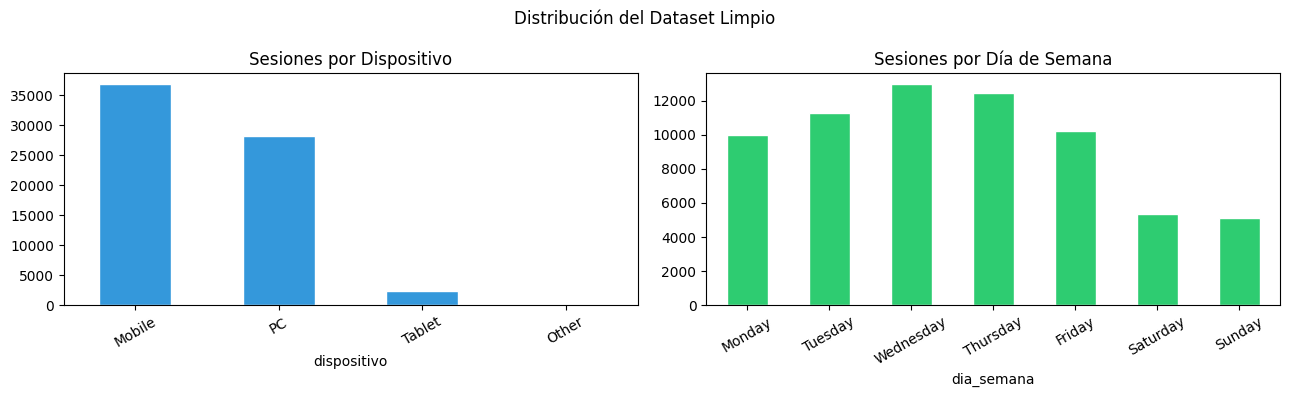

In [20]:
# Distribución de sesiones por dispositivo y día de semana
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['dispositivo'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Sesiones por Dispositivo')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['dia_semana'].value_counts().reindex(orden_dias).plot(kind='bar', ax=axes[1],
                                                          color='#2ecc71', edgecolor='white')
axes[1].set_title('Sesiones por Día de Semana')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.suptitle('Distribución del Dataset Limpio', fontsize=12)
plt.tight_layout()
plt.show()

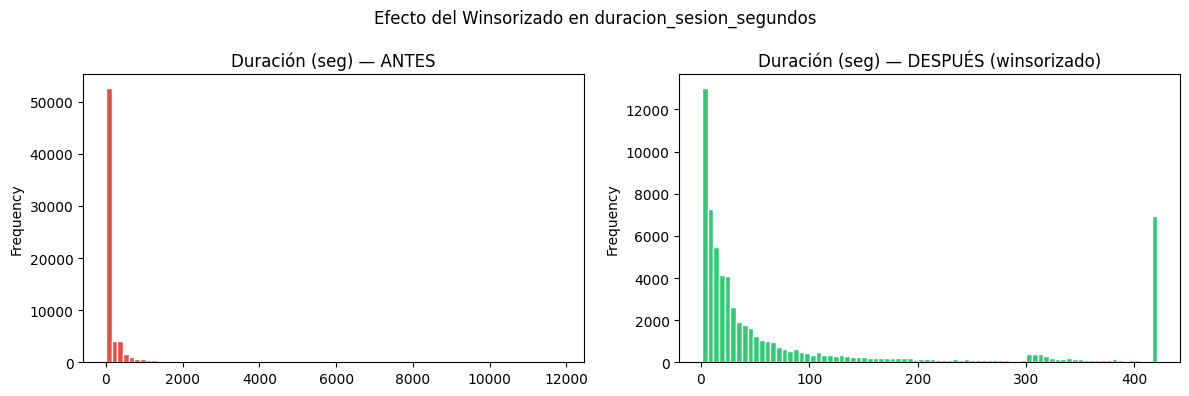

In [21]:
# Comparación duración antes vs después del winsorizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['duracion_sesion_segundos_original'].plot(kind='hist', bins=80, ax=axes[0],
                                              color='#e74c3c', edgecolor='white')
axes[0].set_title('Duración (seg) — ANTES')

df['duracion_sesion_segundos'].plot(kind='hist', bins=80, ax=axes[1],
                                     color='#2ecc71', edgecolor='white')
axes[1].set_title('Duración (seg) — DESPUÉS (winsorizado)')

plt.suptitle('Efecto del Winsorizado en duracion_sesion_segundos')
plt.tight_layout()
plt.show()

In [22]:
print('=== VISTA PREVIA DEL DATASET LIMPIO ===')
df.head(10)

=== VISTA PREVIA DEL DATASET LIMPIO ===


,fecha,hora,duracion_sesion,direccion_url_entrada,direccion_url_salida,referente,id_usuario_clarity,explorador,dispositivo,sistema_operativo,...,trafico_externo,datetime_sesion,dia_semana,mes,duracion_sesion_hms,duracion_sesion_seg_calc,duracion_sesion_segundos_original,clicks_por_pagina_original,tiempo_por_pagina_original,clics_sesion_original
0,2026-03-13,10:49:00,00:00:16,https://cloudlabslearning.com,https://cloudlabslearning.com,https://www.google.com/,bx1vzf,Chrome,PC,Windows,...,1,2026-03-13 10:49:00,Friday,3,00:00:16,16,16.0,2.0,16.0,2
1,2026-03-13,10:48:00,00:00:05,https://cloudlabslearning.com,https://cloudlabslearning.com/#error=login_req...,https://www.google.com/,1h7fns5,Chrome,PC,Windows,...,1,2026-03-13 10:48:00,Friday,3,00:00:05,5,5.0,1.0,2.5,2
2,2026-03-13,10:48:00,00:00:06,https://cloudlabslearning.com/#error=login_req...,https://cloudlabslearning.com/#error=login_req...,(directo),15ymnwq,Chrome,PC,Windows,...,0,2026-03-13 10:48:00,Friday,3,00:00:06,6,6.0,2.0,6.0,2
3,2026-03-13,10:46:00,00:00:06,https://cloudlabslearning.com/#error=login_req...,https://cloudlabslearning.com/#error=login_req...,(directo),o27bll,Chrome,PC,Windows,...,0,2026-03-13 10:46:00,Friday,3,00:00:06,6,6.0,3.0,6.0,3
4,2026-03-13,10:46:00,00:00:39,https://cloudlabslearning.com/request-demo?err...,https://cloudlabslearning.com/request-demo?err...,(directo),6791px,ChromeMobile,Mobile,Android,...,0,2026-03-13 10:46:00,Friday,3,00:00:39,39,39.0,5.0,39.0,5
5,2026-03-13,10:45:00,00:00:05,https://cloudlabslearning.com/#error=login_req...,https://cloudlabslearning.com/#error=login_req...,(directo),zsu6oz,Chrome,PC,Windows,...,0,2026-03-13 10:45:00,Friday,3,00:00:05,5,5.0,3.0,5.0,3
6,2026-03-13,10:45:00,00:00:09,https://cloudlabslearning.com/#error=login_req...,https://cloudlabslearning.com/#error=login_req...,(directo),9kr7zc,Chrome,PC,Windows,...,0,2026-03-13 10:45:00,Friday,3,00:00:09,9,9.0,3.0,9.0,3
7,2026-03-13,10:44:00,00:00:05,https://cloudlabslearning.com,https://cloudlabslearning.com,https://www.google.com/,m1i58e,Chrome,PC,Windows,...,1,2026-03-13 10:44:00,Friday,3,00:00:05,5,5.0,3.0,5.0,3
8,2026-03-13,10:40:00,00:00:54,https://cloudlabslearning.com,https://cloudlabslearning.com/#error=login_req...,https://www.google.com/,hc40h,Chrome,PC,Windows,...,1,2026-03-13 10:40:00,Friday,3,00:00:54,54,54.0,2.5,27.0,5
9,2026-03-13,10:39:00,00:00:14,https://cloudlabslearning.com/request-demo?err...,https://cloudlabslearning.com/request-demo?err...,(directo),w4b6r6,ChromeMobile,Mobile,Android,...,0,2026-03-13 10:39:00,Friday,3,00:00:14,14,14.0,1.0,14.0,1


## 💾 6. Exportar dataset limpio

In [23]:
OUTPUT_PATH = '1_Data_Recordings_CLEAN.csv'

df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f'✅ Archivo guardado en: {OUTPUT_PATH}')

# Si estás en Colab, descarga automática:
# from google.colab import files
# files.download(OUTPUT_PATH)

✅ Archivo guardado en: 1_Data_Recordings_CLEAN.csv
